In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import confint_proportions_2indep

# 1. Load dataset
df = pd.read_csv('marketing_AB.csv')

In [2]:
# 2. Define hypothesis
# H0: p_ad = p_psa | H1: p_ad != p_psa
alpha = 0.05

In [3]:
# 3. Calculate metrics
conversion_metrics = df.groupby('test group')['converted'].agg(['count', 'sum', 'mean'])
conversion_metrics.columns = ['Total Users', 'Converted Users', 'Conversion Rate']
print("\nConversion Metrics:")
print(conversion_metrics)



Conversion Metrics:
            Total Users  Converted Users  Conversion Rate
test group                                               
ad               564577            14423         0.025547
psa               23524              420         0.017854


In [4]:
# 4. Choose test (Chi-square for categorical conversion data)
# Create contingency table
contingency_table = pd.crosstab(df['test group'], df['converted'])

In [5]:
# 5. Run test and extract p-value
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square Test P-value: {p_value:.15f}")


Chi-square Test P-value: 0.000000000000200


In [6]:
# 6. Interpret significance based on p-value
is_significant = p_value < alpha
interpretation = "Statistically Significant" if is_significant else "Not Statistically Significant"
decision = "Reject H0" if is_significant else "Fail to Reject H0"
print(f"Result: {interpretation} ({decision})")

Result: Statistically Significant (Reject H0)


In [7]:
# 7. Calculate confidence interval for difference
# Extract values for the two groups
n_ad = conversion_metrics.loc['ad', 'Total Users']
conv_ad = conversion_metrics.loc['ad', 'Converted Users']
n_psa = conversion_metrics.loc['psa', 'Total Users']
conv_psa = conversion_metrics.loc['psa', 'Converted Users']

In [8]:
# Calculate 95% CI for the difference in proportions (ad - psa)
ci_low, ci_high = confint_proportions_2indep(conv_ad, n_ad, conv_psa, n_psa, method='wald')
lift = conversion_metrics.loc['ad', 'Conversion Rate'] - conversion_metrics.loc['psa', 'Conversion Rate']

/tmp/ipython-input-3062081322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_metrics.index, y=conversion_metrics['Conversion Rate'], palette='magma')


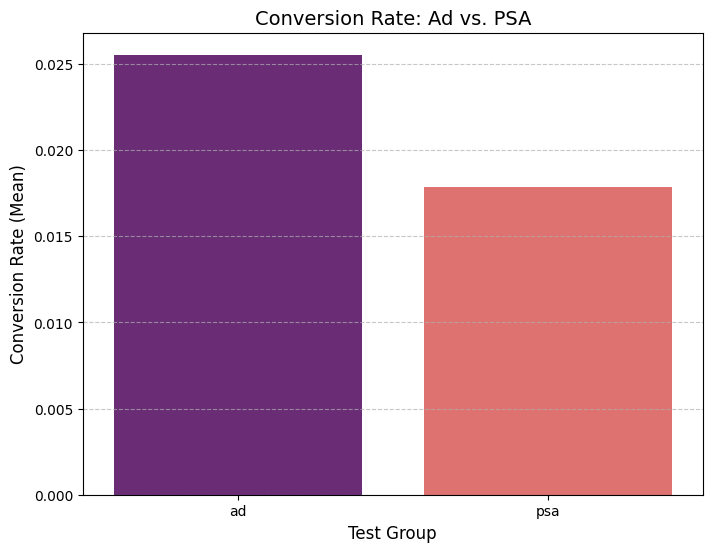

In [9]:
# 8. Visualize group distributions
plt.figure(figsize=(8, 6))
sns.barplot(x=conversion_metrics.index, y=conversion_metrics['Conversion Rate'], palette='magma')
plt.title('Conversion Rate: Ad vs. PSA', fontsize=14)
plt.ylabel('Conversion Rate (Mean)', fontsize=12)
plt.xlabel('Test Group', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('conversion_distribution.png')

In [10]:
# 9. Final decision and business recommendation
recommendation = "The ad campaign significantly increased conversions. Scale the ad campaign." if lift > 0 and is_significant else "The ads did not show a significant positive impact."

# Create and save summary.csv
summary_data = {
    'Metric': [
        'Control (psa) Conv Rate',
        'Test (ad) Conv Rate',
        'Absolute Lift',
        'P-value',
        '95% CI Lower',
        '95% CI Upper',
        'Is Significant',
        'Recommendation'
    ],
    'Value': [
        conversion_metrics.loc['psa', 'Conversion Rate'],
        conversion_metrics.loc['ad', 'Conversion Rate'],
        lift,
        p_value,
        ci_low,
        ci_high,
        is_significant,
        recommendation
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('summary.csv', index=False)

print("\nFinal Summary Table:")
print(summary_df)


Final Summary Table:
                    Metric                                              Value
0  Control (psa) Conv Rate                                           0.017854
1      Test (ad) Conv Rate                                           0.025547
2            Absolute Lift                                           0.007692
3                  P-value                                                0.0
4             95% CI Lower                                           0.005951
5             95% CI Upper                                           0.009434
6           Is Significant                                               True
7           Recommendation  The ad campaign significantly increased conver...
